# 支持向量机（Support Vector Machine，简称 SVM）

## SVM 分类流程
- 选择一个超平面：找到一个能够最大化分类边界的超平面。
- 训练支持向量：通过支持向量机算法，选择离超平面最近的样本点作为支持向量。
- 通过最大化间隔来找到最优超平面：选择一个最优超平面，使得间隔最大化。
- 使用核函数处理非线性问题：通过核函数将数据映射到高维空间来解决非线性可分问题。

## 1.导入库

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from dask.array import shape
from sklearn import svm, datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

## 2.加载数据

In [3]:
# 加载数据(鸢尾花数据集)
iris = datasets.load_iris()
X = iris.data[:, :2]  #只使用前两个特征
y = iris.target


## 3.划分训练集和测试集

In [4]:
# 将数据划分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


## 4.训练SVM模型

In [5]:
# 创建SVM分类器
clf = svm.SVC(kernel='linear')  # 使用线性核函数

# 训练模型
clf.fit(X_train, y_train)


,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


## 5.预测与评估

In [7]:
# 在测试集上进行预测
y_pred = clf.predict(X_test)

# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"模型准确率: {accuracy:.2f}")


模型准确率: 0.80


## 6.可视化结果

C:\Users\10713\AppData\Local\Temp\ipykernel_6384\1942732247.py:10: UserWarning: The following kwargs were not used by contour: 'appha'
  plt.contourf(xx, yy, Z, appha=0.8)


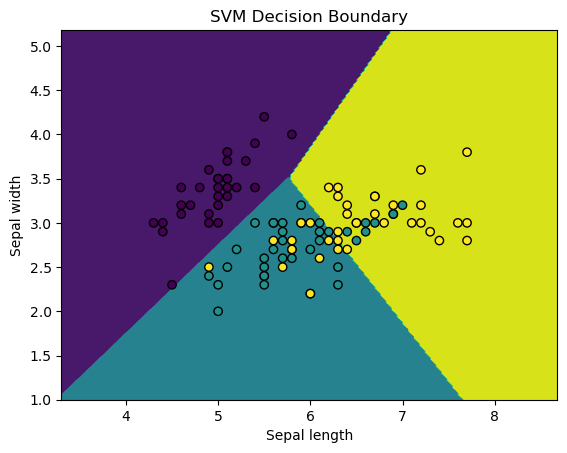

In [9]:
# 绘制决策边界
def plot_decision_boundary(X, y, model):
    h = .02  #网格步长
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, appha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
    plt.xlabel('Sepal length')
    plt.ylabel('Sepal width')
    plt.title('SVM Decision Boundary')
    plt.show()

plot_decision_boundary(X_train,y_train,clf)